<p align="center">
  <img src="https://raw.githubusercontent.com/paulmunozpauta/Hidrology_Course/main/Static/Imgs/UdeC_color_horizontal.jpg" width="500">
</p>
<p align="center"><b style="font-size:28px;">Facultad de Ingeniería Agrícola</b></p>
<p align="center"><b style="font-size:28px;">Curso de Hidrología</b></p>
<hr>
<p align="center"><b style="font-size:28px;">Contacto</b></p>
<p align="center">
  paulmunoz@udec.cl<br>
  https://paulmunoz.com
</p>

# Precipitación

## Objetivo

En este notebook aprenderemos a **procesar, analizar y evaluar datos pluviométricos** de una estación real en Chile, utilizando herramientas de Python orientadas al análisis hidrológico.

Al finalizar este notebook, el estudiante será capaz de:

- Leer y preprocesar series de tiempo de precipitación en formato DGA.
- Visualizar registros diarios y acumulados.
- Aplicar métodos de **relleno de datos faltantes** (promedio simple y razón normal).
- Evaluar la **homogeneidad** de una serie mediante la curva de doble masa.
- Calcular e interpretar la **intensidad de precipitación**.

---


**Fuente de datos:** En Chile, la Dirección General de Aguas (DGA) y la Dirección Meteorológica de Chile (DMC) mantienen redes de estaciones pluviométricas. Los datos están disponibles en: https://explorador.cr2.cl/


# 1. Configuración del entorno

## 1.1 Clonar el repositorio desde GitHub

Para acceder a los datos y scripts del curso, clonaremos el repositorio desde GitHub. Esto descarga todos los archivos necesarios en el entorno de Google Colab.

> ⚠️ **Nota:** Esta celda solo debe ejecutarse **una vez** por sesión. Si el repositorio ya fue clonado, puedes omitir este paso.

In [67]:
# Clona el repositorio del curso desde GitHub en el entorno de Google Colab.
!git clone -- https://github.com/paulmunozpauta/Hidrology_Course

Cloning into 'Hidrology_Course'...
remote: Enumerating objects: 170, done.
remote: Counting objects: 100% (132/132), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 170 (delta 58), reused 50 (delta 13), pack-reused 38 (from 1)
Receiving objects: 100% (170/170), 64.17 MiB | 21.21 MiB/s, done.
Resolving deltas: 100% (64/64), done.
Updating files: 100% (22/22), done.


Después de ejecutar la celda anterior, se crea una carpeta llamada **`Hidrology_Course`** en el entorno de trabajo. Esta carpeta contiene todos los archivos del curso, incluyendo los datos pluviométricos que usaremos a continuación.

## 1.2 Ingresar a la carpeta del repositorio

Cambiamos el directorio de trabajo para que Python pueda encontrar los archivos de datos mediante rutas relativas.

# Entrar a la carpeta del repositorio





In [68]:
# Cambia el directorio de trabajo actual a la carpeta del repositorio clonado.
# El comando mágico %cd de Jupyter/Colab cambia el directorio de forma persistente
%cd Hidrology_Course
# Muestra los archivos disponibles en la carpeta actual para verificar
# que el repositorio se clonó correctamente.
!ls

/content/Hidrology_Course/Hidrology_Course/Hidrology_Course/Hidrology_Course
01_Delimitacion_cuenca.ipynb	   03_Precipitación.ipynb  README.md
02_Probabilidad_estadística.ipynb  Data			   Static



# 2. Instalación e importación de librerías

Las siguientes librerías son fundamentales para el análisis hidrológico en Python:

| Librería | Uso principal en este notebook |
|----------|--------------------------------|
| `pandas` | Manejo de series de tiempo y DataFrames |
| `numpy` | Operaciones numéricas y manejo de valores nulos |
| `matplotlib` | Visualización de datos (gráficos y figuras) |
| `os` | Interacción con el sistema de archivos |



Librerías principales:
pandas
numpy
matplotlib

In [69]:
# Instala (o actualiza) la librería pandas desde PyPI.
!pip install -q pandas

In [70]:
# os: permite interactuar con rutas y directorios del sistema operativo.
import os

# numpy: librería de computación numérica. Se usa para operaciones vectoriales
# y para trabajar con valores nulos (np.nan).
import numpy as np

# matplotlib.pyplot: módulo de visualización. Permite crear gráficos de líneas,
# barras, dispersión, etc.
import matplotlib.pyplot as plt

# pandas: librería principal para análisis de datos tabulares y series de tiempo.
# Se usará para leer los archivos Excel y manipular los datos pluviométricos.
import pandas as pd

print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.



# 3. Lectura de datos hidrometeorológicos

## Estación Puerto Montt – DGA (código 10425001)

Trabajaremos con datos de la estación **Puerto Montt**, ubicada en la Región de Los Lagos. Esta estación pertenece a la red de la Dirección General de Aguas (DGA) de Chile.

**¿Por qué Puerto Montt?**

Puerto Montt es una de las ciudades más lluviosas de Chile, con precipitaciones anuales que superan los 1.800 mm. Su régimen pluviométrico es del tipo **oceánico templado**, con lluvias distribuidas a lo largo de todo el año y un leve máximo invernal.

**Formato de los datos DGA:**

Los archivos descargados del explorador del CR2 (https://explorador.cr2.cl/) suelen tener columnas separadas para año (`agno`), mes (`mes`), día (`dia`) y valor de precipitación diaria (`valor`), en lugar de una columna de fecha completa. Este formato requiere un paso de preprocesamiento que veremos a continuación.

In [71]:
# Define la ruta relativa al archivo de datos de la estación Puerto Montt.
# Al haber cambiado el directorio con %cd, la ruta parte desde la raíz del repositorio.
archivo = "Data/Precipitación/PuertoMontt_DGA_10425001.xlsx"

# Lee el archivo Excel y carga los datos en un DataFrame de pandas.
# Un DataFrame es una tabla bidimensional con filas y columnas etiquetadas.
PMontt = pd.read_excel(archivo)

# Muestra las primeras filas del DataFrame para verificar la estructura de los datos.
print(f"Dimensiones del dataset: {PMontt.shape[0]} filas × {PMontt.shape[1]} columnas\n")
PMontt.head(10)

Dimensiones del dataset: 17482 filas × 4 columnas



,agno,mes,dia,valor
0,1973,2,1,0.0
1,1973,2,2,0.0
2,1973,2,3,0.0
3,1973,2,4,0.0
4,1973,2,5,0.0
5,1973,2,6,3.0
6,1973,2,7,12.5
7,1973,2,8,7.3
8,1973,2,9,0.0
9,1973,2,10,7.5



# 4. Preprocesamiento de datos

## ¿Por qué es necesario el preprocesamiento?

Los datos crudos de la DGA presentan varias situaciones que deben resolverse antes de cualquier análisis:

1. **Columnas separadas de año, mes y día:** Deben unirse para formar una fecha válida.
2. **Nombres de columnas inconsistentes:** Pueden tener espacios, acentos o variaciones    ortográficas según la versión del archivo.
3. **Valores no numéricos:** Algunos registros pueden contener texto (e.g., códigos de error).    Se deben convertir a numérico, forzando los no válidos a `NaN`.
4. **Fechas inválidas:** Por ejemplo, el 31 de febrero, que no existe. Deben eliminarse.
5. **Ordenamiento temporal:** Los datos deben estar ordenados cronológicamente.

El preprocesamiento es un paso crítico en hidrología: datos mal formateados pueden producir errores en cálculos estadísticos, análisis de frecuencia y diseño hidrológico.

Los datos diarios de esta estación están separados en columnas por "agno", "mes", "día" y "valor".

Vamos a generar una serie (dataframe) ordenada cronológicamente a través de la fecha disponible

In [76]:
# limpiar nombres de columnas
PMontt.columns = PMontt.columns.str.strip().str.lower()

# renombrar por seguridad si vienen con espacios o acentos raros
PMontt = PMontt.rename(columns={
    "agno": "anio",
    "año": "anio",
    "mes": "mes",
    "dia": "dia",
    "valor": "precipitacion_diaria_mm"
})

# convertir columnas a numéricas
for col in ["anio", "mes", "dia", "precipitacion_diaria_mm"]:
    PMontt[col] = pd.to_numeric(PMontt[col], errors="coerce")

# eliminar filas con datos faltantes en columnas clave
PMontt = PMontt.dropna(subset=["anio", "mes", "dia", "precipitacion_diaria_mm"])

# convertir año, mes y día a enteros
PMontt["anio"] = PMontt["anio"].astype(int)
PMontt["mes"] = PMontt["mes"].astype(int)
PMontt["dia"] = PMontt["dia"].astype(int)

# crear columna fecha
PMontt["fecha"] = pd.to_datetime(
    dict(year=PMontt["anio"], month=PMontt["mes"], day=PMontt["dia"]),
    errors="coerce"
)

# eliminar fechas inválidas
PMontt = PMontt.dropna(subset=["fecha"])

# dejar solo la serie temporal final
PMontt = PMontt[["fecha", "precipitacion_diaria_mm"]].copy()

# ordenar por fecha
PMontt = PMontt.sort_values("fecha").reset_index(drop=True)

# opcional: usar fecha como índice
PMontt = PMontt.set_index("fecha")

# mostrar la serie
PMontt


,precipitacion_diaria_mm
fecha,
1973-02-01,0.0
1973-02-02,0.0
1973-02-03,0.0
1973-02-04,0.0
1973-02-05,0.0
...,...
2025-04-22,0.2
2025-04-23,0.2
2025-04-24,2.3


# 5. Visualización de la serie de precipitación diaria

Antes de realizar cualquier análisis, es fundamental **visualizar los datos** para:
- Detectar tendencias generales y estacionalidad.
- Identificar posibles errores o datos atípicos (*outliers*).
- Comprender el régimen pluviométrico de la estación.

>  **¿Por qué no graficamos como barras toda la serie?**
>
> La precipitación diaria se representa conceptualmente como barras, ya que cada valor corresponde a una acumulación en un intervalo de tiempo. Sin embargo, graficar decenas de miles de barras tiene un costo computacional elevado y la visualización pierde claridad. Para la serie completa usaremos líneas; las barras las reservamos para períodos más cortos.


<Figure size 1200x500 with 0 Axes>

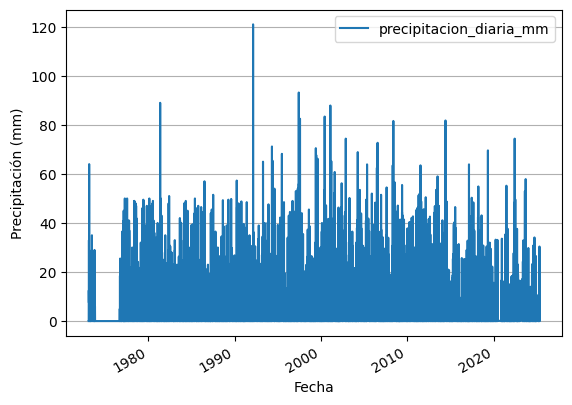

In [77]:
plt.figure(figsize=(12,5))
PMontt.plot()#no lo hacemos como barras por la carga computacional
plt.xlabel("Fecha")
plt.ylabel("Precipitación (mm)")
plt.grid(axis="y")
plt.show()

# 6. Relleno de datos faltantes

## ¿Por qué faltan datos en estaciones pluviométricas?

En la práctica, las series de precipitación raramente son completas. Los registros pueden faltar por fallas del instrumento, problemas de comunicación, errores del observador, o simplemente porque la estación no operaba en ese período.

**Impacto de los datos faltantes:**

Los datos faltantes afectan directamente los cálculos de:
- Precipitación media anual (módulo pluviométrico)
- Balances hídricos
- Análisis de frecuencia de eventos extremos

## Criterio para elegir el método de relleno

La elección del método depende de qué tan diferente es el régimen pluviométrico de la estación con datos faltantes ($P_x$) respecto a las estaciones vecinas usadas como referencia.

El criterio se basa en el **módulo pluviométrico** ($M$): la precipitación media anual histórica de cada estación.

| Condición | Método recomendado |
|-----------|--------------------|
| Diferencia entre módulos < 10% | Método 1: Promedio aritmético simple |
| Diferencia entre módulos ≥ 10% | Método 2: Razón normal ponderada |

## Visualización del año 2022 (antes de introducir datos faltantes)

Para ilustrar el proceso, primero visualizamos el año 2022 completo en forma de barras diarias y luego como precipitación acumulada.

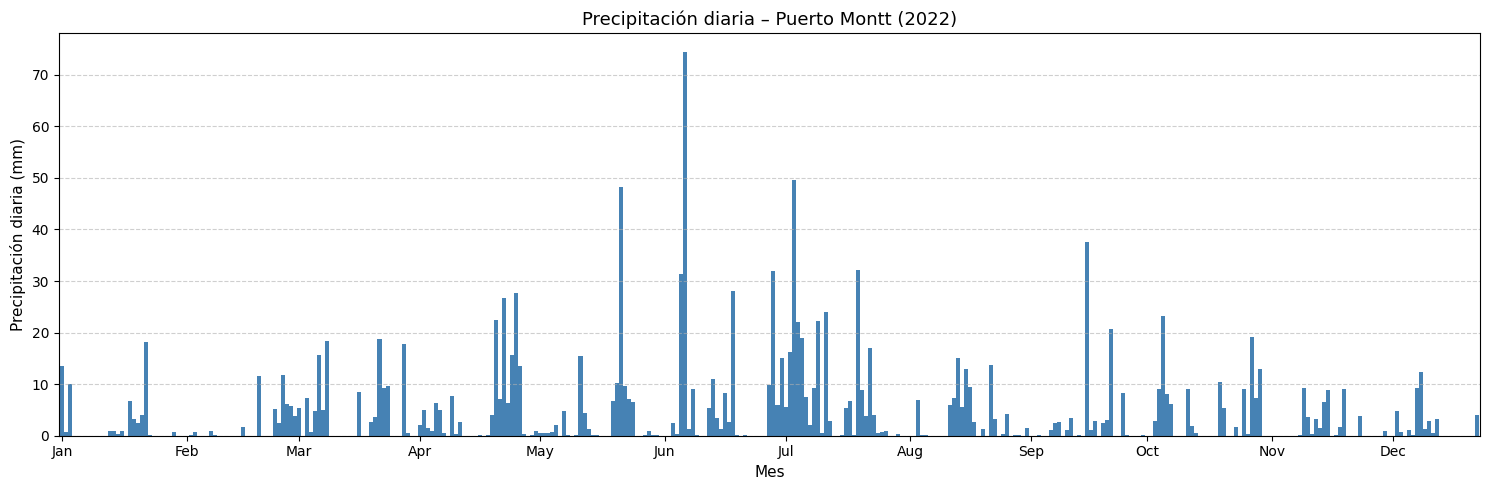

In [79]:

# ── Gráfico 1: Precipitación diaria de 2022 en barras ────────────────────────
# Seleccionamos solo los datos del año 2022 usando indexación por etiqueta de fecha.
data_2022 = PMontt.loc["2022"]

fig, ax = plt.subplots(figsize=(15, 5))
data_2022.plot(kind="bar", ax=ax, color="steelblue", width=1.0, legend=False)

# Configuramos las etiquetas del eje X para mostrar solo el nombre del mes
# (en lugar de cada día, que sería ilegible).
dates = data_2022.index
month_positions = [i for i, d in enumerate(dates) if d.day == 1]
month_labels    = [d.strftime("%b") for d in dates if d.day == 1]
ax.set_xticks(month_positions)
ax.set_xticklabels(month_labels, rotation=0)

plt.xlabel("Mes", fontsize=11)
plt.ylabel("Precipitación diaria (mm)", fontsize=11)
plt.title("Precipitación diaria – Puerto Montt (2022)", fontsize=13)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

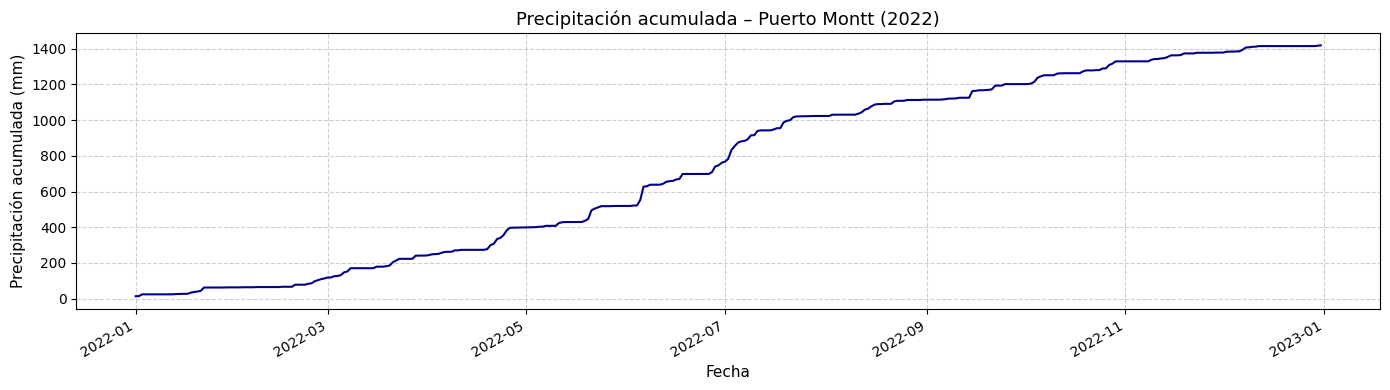

In [80]:
# ── Gráfico 2: Precipitación acumulada de 2022 ───────────────────────────────
# .cumsum() calcula la suma acumulada: cada punto representa la precipitación
# total desde el 1 de enero hasta esa fecha.
# Esta representación es útil para detectar períodos secos o húmedos inusualmente largos.
fig, ax = plt.subplots(figsize=(14, 4))
data_2022.cumsum().plot(ax=ax, color="darkblue", linewidth=1.5, legend=False)

plt.xlabel("Fecha", fontsize=11)
plt.ylabel("Precipitación acumulada (mm)", fontsize=11)
plt.title("Precipitación acumulada – Puerto Montt (2022)", fontsize=13)
plt.grid(linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 6.1 Simulación de datos faltantes

Para demostrar los métodos de relleno, **introduciremos artificialmente** datos faltantes en el período del 1 al 15 de julio de 2022. Esto nos permitirá comparar los valores estimados por cada método contra los valores originales.

In [81]:
# Guardamos una copia de la serie original ANTES de eliminar datos.
# Esta copia nos servirá posteriormente para evaluar la calidad del relleno
# comparando los valores estimados con los valores reales.
PMontt_original = PMontt.copy()

# Reemplazamos los valores del 1 al 15 de julio de 2022 con NaN (Not a Number),
# que es la forma estándar de representar datos faltantes en pandas/numpy.
PMontt.loc["2022-07-01":"2022-07-15"] = np.nan

print("Datos eliminados en el período 2022-07-01 a 2022-07-15:")
print(f"  Registros con NaN: {PMontt.loc['2022-07-01':'2022-07-15'].isna().sum().values[0]}")

Datos eliminados en el período 2022-07-01 a 2022-07-15:
  Registros con NaN: 15


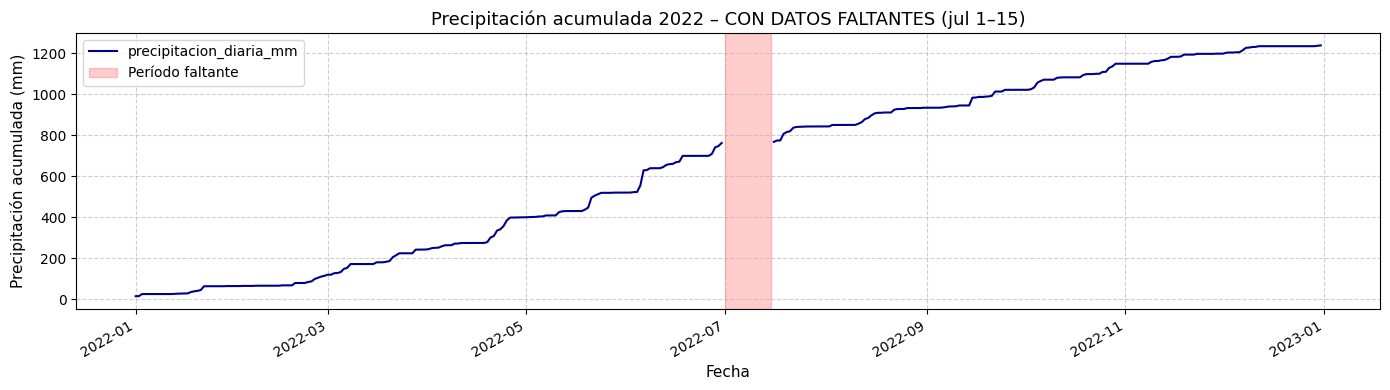

In [82]:
# Verificamos visualmente el efecto de los datos faltantes en la curva acumulada.
# La curva debería "aplanarse" (dejar de crecer) durante el período sin datos.
fig, ax = plt.subplots(figsize=(14, 4))
PMontt.loc["2022"].cumsum().plot(ax=ax, color="darkblue", linewidth=1.5, legend=False)

plt.xlabel("Fecha", fontsize=11)
plt.ylabel("Precipitación acumulada (mm)", fontsize=11)
plt.title("Precipitación acumulada 2022 – CON DATOS FALTANTES (jul 1–15)", fontsize=13)
plt.grid(linestyle="--", alpha=0.6)

# Marcamos el período faltante con una banda gris para visualizarlo claramente.
ax.axvspan(pd.Timestamp("2022-07-01"), pd.Timestamp("2022-07-15"),
           alpha=0.2, color="red", label="Período faltante")
ax.legend()
plt.tight_layout()
plt.show()

## 6.2 Selección de estaciones vecinas

Para aplicar los métodos de relleno, necesitamos al menos tres estaciones cercanas con datos simultáneos y alta correlación con la estación en análisis.

Las estaciones disponibles se pueden verificar en: https://explorador.cr2.cl/

<p align="center">
  <img src="https://raw.githubusercontent.com/paulmunozpauta/Hidrology_Course/main/Static/Imgs/PMontt_estaciones_cercanas.png" width="800">
</p>

Las estaciones candidatas son:

| Código | Nombre | Fuente |
|--------|--------|--------|
| 10430005 | Lago Chapo | DGA |
| 10523001 | Puelo | DGA |
| 410005 | Tepual (Aeropuerto) | DMC |
| 10410015 | Cascada | DGA |

> **¿Cómo elegir las estaciones?** Se recomienda seleccionar estaciones que estén:
> - Dentro de la misma cuenca o región climática.
> - Preferiblemente a menos de 50–100 km de distancia.
> - Con alta correlación estadística (p.ej., r > 0.7) con la estación objetivo.

### Función de preprocesamiento reutilizable

Para cargar las cuatro estaciones vecinas, encapsulamos el proceso de preprocesamiento en una **función** reutilizable. Esto aplica el principio de programación **DRY** (*Don't Repeat Yourself*): evitamos duplicar código y reducimos el riesgo de errores.

In [84]:
def preparar_serie_precipitacion(df):
    """
    Preprocesa un DataFrame con datos pluviométricos en formato DGA.

    El formato DGA presenta las columnas de año (agno), mes, día y valor
    separadas. Esta función las unifica en una serie de tiempo indexada por fecha.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con columnas: agno/año, mes, dia/día, valor/precipitacion.

    Returns
    -------
    pd.DataFrame
        Serie temporal con índice de tipo DatetimeIndex y columna
        "precipitacion_diaria_mm", ordenada cronológicamente.
    """
    df = df.copy()  # Evitamos modificar el DataFrame original (buena práctica)

    # Normalizar nombres de columnas
    df.columns = df.columns.str.strip().str.lower()

    # Mapa de posibles nombres de columnas en archivos DGA/DMC
    df = df.rename(columns={
        "agno": "anio", "año": "anio", "ano": "anio",
        "mes": "mes",
        "dia": "dia", "día": "dia",
        "valor": "precipitacion_diaria_mm",
        "precipitacion": "precipitacion_diaria_mm",
        "precipitación": "precipitacion_diaria_mm",
        "precipitacion_diaria": "precipitacion_diaria_mm"
    })

    # Convertir a numérico y limpiar nulos
    for col in ["anio", "mes", "dia", "precipitacion_diaria_mm"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["anio", "mes", "dia", "precipitacion_diaria_mm"])

    # Convertir a enteros (requerido por pd.to_datetime)
    df["anio"] = df["anio"].astype(int)
    df["mes"]  = df["mes"].astype(int)
    df["dia"]  = df["dia"].astype(int)

    # Construir columna de fecha y eliminar fechas inválidas
    df["fecha"] = pd.to_datetime(
        dict(year=df["anio"], month=df["mes"], day=df["dia"]),
        errors="coerce"
    )
    df = df.dropna(subset=["fecha"])

    # Retornar serie ordenada con fecha como índice
    df = df[["fecha", "precipitacion_diaria_mm"]].copy()
    df = df.sort_values("fecha").reset_index(drop=True)
    return df.set_index("fecha")

print("✅ Función preparar_serie_precipitacion() definida.")

✅ Función preparar_serie_precipitacion() definida.


In [92]:
# Cargamos los archivos Excel de las cuatro estaciones vecinas.
# pd.read_excel() lee el archivo directamente en un DataFrame.
LagoChapo_raw = pd.read_excel("Data/Precipitación/LagoChapo_DGA_10430005.xlsx")
Puelo_raw     = pd.read_excel("Data/Precipitación/Puelo_DGA_10523001.xlsx")
Tepual_raw    = pd.read_excel("Data/Precipitación/Tepual_DMC_410005.xlsx")
Cascada_raw   = pd.read_excel("Data/Precipitación/Cascada_DGA_10410015.xlsx")

# Aplicamos la función de preprocesamiento a cada estación.
LagoChapo = preparar_serie_precipitacion(LagoChapo_raw)
Puelo     = preparar_serie_precipitacion(Puelo_raw)
Tepual    = preparar_serie_precipitacion(Tepual_raw)
Cascada   = preparar_serie_precipitacion(Cascada_raw)

print("✅ Estaciones cargadas y preprocesadas:")
for nombre, est in [("Lago Chapo", LagoChapo), ("Puelo", Puelo),
                     ("Tepual", Tepual), ("Cascada", Cascada)]:
    print(f"  {nombre}: {len(est)} registros ({est.index.min().date()} → {est.index.max().date()})")

✅ Estaciones cargadas y preprocesadas:
  Lago Chapo: 5974 registros (1999-01-01 → 2015-05-30)
  Puelo: 9342 registros (1996-12-01 → 2025-04-26)
  Tepual: 27754 registros (1950-01-01 → 2025-12-29)
  Cascada: 3167 registros (2015-05-13 → 2025-04-26)


## 6.3 Análisis de correlación

Para seleccionar las **tres mejores estaciones** de relleno, calculamos el **coeficiente de correlación de Pearson** entre la precipitación diaria de Puerto Montt y cada estación vecina.

$$r = \frac{\sum (P_x - \bar{P}_x)(P_i - \bar{P}_i)}{\sqrt{\sum (P_x - \bar{P}_x)^2 \sum (P_i - \bar{P}_i)^2}}$$

El coeficiente $r$ varía entre -1 y 1:
- $r$ cercano a **1**: correlación positiva fuerte (llueve más en ambas al mismo tiempo).
- $r$ cercano a **0**: sin correlación.
- $r$ cercano a **-1**: correlación negativa (cuando llueve en una, no llueve en la otra).

In [95]:
# Concatenamos todas las series en un único DataFrame alineado por fecha.
# pd.concat con axis=1 une columnas (series) compartiendo el índice de fecha.
# Las fechas sin dato en alguna estación quedarán como NaN automáticamente.
df_corr = pd.concat(
    [
        PMontt["precipitacion_diaria_mm"].rename("PuertoMontt"),
        LagoChapo["precipitacion_diaria_mm"].rename("LagoChapo"),
        Puelo["precipitacion_diaria_mm"].rename("Puelo"),
        Tepual["precipitacion_diaria_mm"].rename("Tepual"),
        Cascada["precipitacion_diaria_mm"].rename("Cascada")
    ],
    axis=1
)

# .corr() calcula la matriz de correlación de Pearson entre todas las columnas.
# Seleccionamos solo la columna de Puerto Montt y ordenamos de mayor a menor.
correlaciones = df_corr.corr()["PuertoMontt"].sort_values(ascending=False)

print("Correlación de Pearson con Puerto Montt:")
print(correlaciones.to_string())
print("\n→ Se seleccionan las 3 estaciones con mayor correlación (excluyendo la propia).")

Correlación de Pearson con Puerto Montt:
PuertoMontt    1.000000
Tepual         0.835983
Puelo          0.788956
LagoChapo      0.782591
Cascada        0.538062

→ Se seleccionan las 3 estaciones con mayor correlación (excluyendo la propia).



## 6.4 Método 1: Promedio aritmético simple

**Condición de aplicación:** La precipitación media anual de las estaciones vecinas difiere en **menos del 10%** respecto a la estación con datos faltantes.

**Fórmula:**

$$P_x = \frac{P_a + P_b + P_c}{3}$$

Donde $P_a$, $P_b$ y $P_c$ son las precipitaciones registradas en las tres estaciones vecinas para el mismo día que falta en la estación $P_x$.

**Interpretación:** Este método asume que todas las estaciones contribuyen igualmente al estimado. Es simple y efectivo cuando las estaciones presentan condiciones climáticas similares.

In [96]:
# Unimos todas las series en un DataFrame consolidado.
# Incluimos tanto la serie con datos faltantes como la original (para comparar).
df_todas_estaciones = pd.concat(
    [
        PMontt["precipitacion_diaria_mm"].rename("PuertoMontt"),
        PMontt_original["precipitacion_diaria_mm"].rename("PuertoMontt_original"),
        Tepual["precipitacion_diaria_mm"].rename("Tepual"),
        Puelo["precipitacion_diaria_mm"].rename("Puelo"),
        Cascada["precipitacion_diaria_mm"].rename("Cascada"),
    ],
    axis=1
)

# Visualizamos el período alrededor de los datos faltantes para verificar la alineación.
print("Datos en torno al período faltante (2022-06-28 a 2022-07-20):")
df_todas_estaciones.loc["2022-06-28":"2022-07-20"]

Datos en torno al período faltante (2022-06-28 a 2022-07-20):


,PuertoMontt,PuertoMontt_original,Tepual,Puelo,Cascada
fecha,,,,,
2022-06-28,32.0,32.0,20.0,37.5,37.8
2022-06-29,6.0,6.0,5.4,11.4,0.1
2022-06-30,15.1,15.1,13.6,11.4,2.4
2022-07-01,NaN,5.5,3.8,9.6,5.6
2022-07-02,NaN,16.2,16.6,28.8,16.7
2022-07-03,NaN,49.6,36.0,60.8,15.2
2022-07-04,NaN,22.1,17.6,32.6,14.7
2022-07-05,NaN,19.0,15.0,31.1,13.4
2022-07-06,NaN,7.6,7.2,21.4,4.1


In [60]:
# -----------------------------------------
# Crear columna SOLO con valores estimados
# para el período 1–15 julio 2022
# -----------------------------------------

# Inicializar columna vacía
df_todas_estaciones["Relleno_PM"] = np.nan

# Definir período
periodo_relleno = slice("2022-07-01", "2022-07-15")

# Calcular relleno por promedio simple
df_todas_estaciones.loc[periodo_relleno, "Relleno_PM"] = (
    df_todas_estaciones.loc[periodo_relleno, ["Tepual", "Puelo", "LagoChapo"]]
    .mean(axis=1)
)


# Ver resultados
df_todas_estaciones.loc[
    periodo_relleno,
    ["PuertoMontt_original","PuertoMontt", "Relleno_PM", "Tepual", "Puelo", "LagoChapo"]
]

,PuertoMontt_original,PuertoMontt,Relleno_PM,Tepual,Puelo,LagoChapo
fecha,,,,,,
2022-07-01,5.5,NaN,7.266667,3.8,9.6,8.4
2022-07-02,16.2,NaN,21.566667,16.6,28.8,19.3
2022-07-03,49.6,NaN,42.633333,36.0,60.8,31.1
2022-07-04,22.1,NaN,19.266667,17.6,32.6,7.6
2022-07-05,19.0,NaN,20.666667,15.0,31.1,15.9
2022-07-06,7.6,NaN,13.033333,7.2,21.4,10.5
2022-07-07,2.0,NaN,2.733333,1.2,5.3,1.7
2022-07-08,9.3,NaN,16.033333,6.4,20.2,21.5
2022-07-09,22.3,NaN,13.566667,9.6,13.6,17.5


### Método 2

Si el modulo pluviometrico entre estaciones difiere es mayor al 10 %
Otro metoddo mas robusto
𝑃_𝑥/𝑀_𝑥 =(𝑃_𝑎/𝑀_𝑎 +𝑃_𝑏/𝑀_𝑏 +𝑃_𝑐/𝑀_𝑐 )/3  donde 𝑀_𝑖 es el promedio histórico anual

In [61]:
# -----------------------------------------
# Método robusto: razón normal
# Px/Mx = promedio(Pi/Mi)
# M = precipitación media anual histórica
# -----------------------------------------

# 1. Calcular precipitación anual por estación
precipitacion_anual = df_todas_estaciones[
    ["PuertoMontt", "Tepual", "Puelo", "LagoChapo"]
].resample("Y").sum(min_count=300)

# 2. Calcular módulo pluviométrico: precipitación media anual histórica
modulos = precipitacion_anual.mean()

modulos

# 3. Extraer módulos
Mx = modulos["PuertoMontt"]
Ma = modulos["Tepual"]
Mb = modulos["Puelo"]
Mc = modulos["LagoChapo"]

# 4. Crear columna vacía para relleno con método robusto
df_todas_estaciones["Relleno_PM_modulo"] = np.nan

# 5. Definir período a rellenar
periodo_relleno = slice("2022-07-01", "2022-07-15")

# 6. Aplicar método ponderado por módulo
df_todas_estaciones.loc[periodo_relleno, "Relleno_PM_modulo"] = Mx * (
    (
        df_todas_estaciones.loc[periodo_relleno, "Tepual"] / Ma
        + df_todas_estaciones.loc[periodo_relleno, "Puelo"] / Mb
        + df_todas_estaciones.loc[periodo_relleno, "LagoChapo"] / Mc
    ) / 3
)

# 7. Ver comparación
df_todas_estaciones.loc[
    periodo_relleno,
    [
        "PuertoMontt_original",
        "PuertoMontt",
        "Relleno_PM",
        "Relleno_PM_modulo",
        "Tepual",
        "Puelo",
        "LagoChapo"
    ]
]

/tmp/ipykernel_12414/3256027702.py:10: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  ].resample("Y").sum(min_count=300)


,PuertoMontt_original,PuertoMontt,Relleno_PM,Relleno_PM_modulo,Tepual,Puelo,LagoChapo
fecha,,,,,,,
2022-07-01,5.5,NaN,7.266667,5.556052,3.8,9.6,8.4
2022-07-02,16.2,NaN,21.566667,17.023123,16.6,28.8,19.3
2022-07-03,49.6,NaN,42.633333,33.832215,36.0,60.8,31.1
2022-07-04,22.1,NaN,19.266667,15.232867,17.6,32.6,7.6
2022-07-05,19.0,NaN,20.666667,16.088097,15.0,31.1,15.9
2022-07-06,7.6,NaN,13.033333,9.847273,7.2,21.4,10.5
2022-07-07,2.0,NaN,2.733333,2.002870,1.2,5.3,1.7
2022-07-08,9.3,NaN,16.033333,12.092723,6.4,20.2,21.5
2022-07-09,22.3,NaN,13.566667,10.792174,9.6,13.6,17.5


Compracion de curvas acumuladas

<Figure size 1500x600 with 0 Axes>

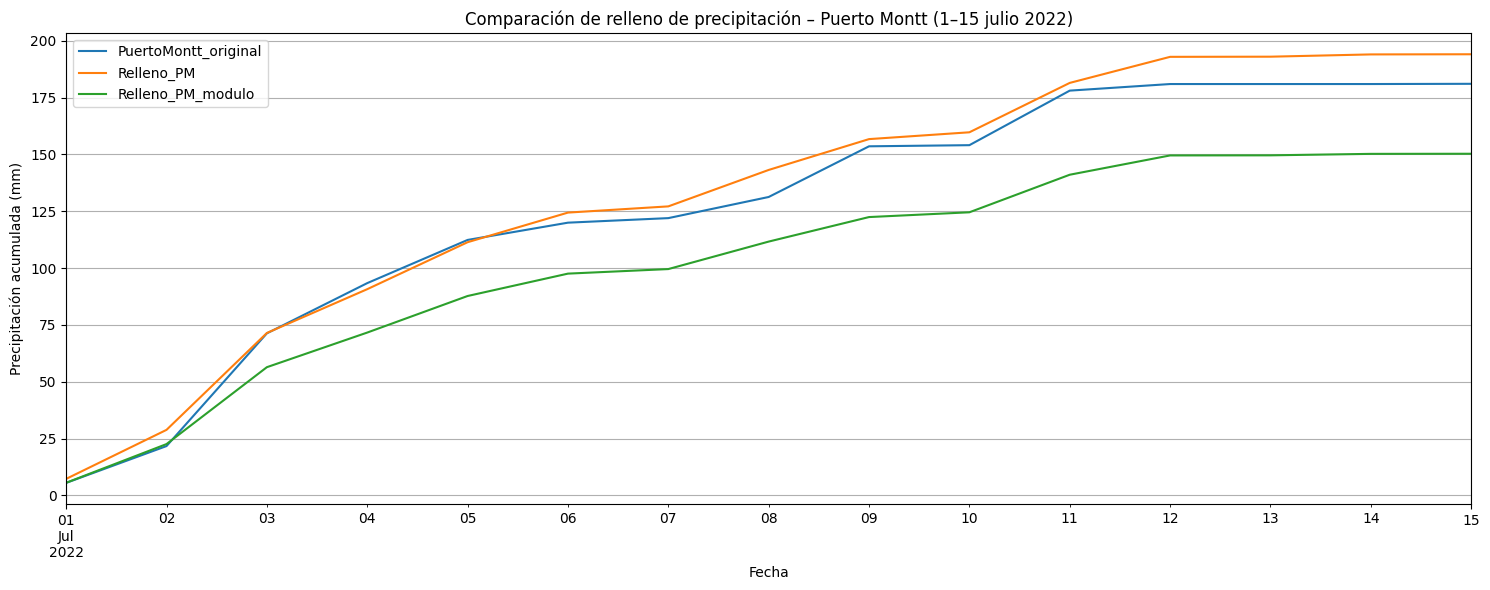

In [62]:
plt.figure(figsize=(15,6))

# Seleccionar período y columnas correctamente
data_to_plot = df_todas_estaciones.loc[
    "2022-07-01":"2022-07-15",
    ["PuertoMontt_original", "Relleno_PM", "Relleno_PM_modulo"]
].cumsum()

# Graficar
ax = data_to_plot.plot(figsize=(15,6))

# Etiquetas
plt.xlabel("Fecha")
plt.ylabel("Precipitación acumulada (mm)")
plt.title("Comparación de relleno de precipitación – Puerto Montt (1–15 julio 2022)")



plt.grid(True)
plt.tight_layout()
plt.show()

## Homogeneidad

### Curva de doble masa:

Sirven para la evaluación de consistencia y homogeneidad de series pluviométricas.
**La curva de doble masa permite distinguir entre cambios climáticos reales y alteraciones artificiales en la medición.**

Las series de precipitación registradas en una estación pueden verse afectadas por factores distintos a cambios climáticos reales. Alteraciones en el entorno (urbanización, vegetación, obstáculos), cambio de ubicación de la estación, reemplazo del instrumento o variaciones en el observador pueden generar modificaciones artificiales en los datos medidos, produciendo aumentos o disminuciones que no representan necesariamente cambios verdaderos en la precipitación.

Para detectar estas posibles inconsistencias, se utiliza el método de la **curva de doble masa**, una herramienta clásica para evaluar la homogeneidad de una serie pluviométrica.


#### Principio del método

El procedimiento consiste en comparar la **precipitación acumulada de la estación en análisis** con la **precipitación acumulada de una serie patrón**, generalmente construida a partir del promedio de varias estaciones vecinas representativas.

Si la estación mantiene condiciones homogéneas y la región presenta comportamiento pluviométrico similar, ambas series deberían guardar una relación proporcional:

$$
P_x = \alpha P_p + \varepsilon
$$

Donde:

- $P_x$: precipitación de la estación analizada  
- $P_p$: precipitación patrón (promedio de estaciones vecinas)  
- $\alpha$: constante de proporcionalidad  
- $\varepsilon$: error aleatorio o dispersión residual  

Al acumular en el tiempo:

$$
\sum P_x \approx \alpha \sum P_p
$$

Como los errores aleatorios tienden a compensarse, una estación homogénea debería producir una relación aproximadamente lineal.


#### Interpretación de la curva

**Serie homogénea:**  
Si la curva acumulada es aproximadamente una línea recta que pasa por el origen, la estación mantiene una relación estable con el patrón y sus datos pueden considerarse consistentes.

**Cambio de pendiente:**  
Si aparecen dos o más tramos con pendientes distintas, esto puede indicar cambios en las condiciones de medición, tales como:

- Cambio de instrumento  
- Reubicación  
- Modificaciones ambientales  
- Problemas operacionales  

Una pendiente mayor puede sugerir sobreestimación, mientras que una menor puede indicar subestimación respecto al patrón.


#### Corrección de series

Si se detecta una discontinuidad clara y persistente, los datos pueden ajustarse mediante:

$$
P_c = P_m \frac{\alpha_1}{\alpha_i}
$$

Donde:

- $P_c$: precipitación corregida  
- $P_m$: precipitación medida  
- $\alpha_i$: pendiente del tramo inconsistente  
- $\alpha_1$: pendiente del período de referencia  

Por convención, suele usarse como referencia el período más reciente o el más confiable.

#### Recomendaciones prácticas

- No corregir cambios poco notorios  
- Evitar ajustes si la anomalía dura menos de ~5 años  
- Investigar causas físicas o instrumentales antes de corregir  
- Revisar también la homogeneidad de las estaciones patrón  
- Aplicar el proceso de forma iterativa  


#### Desplazamientos bruscos

Si la curva presenta un salto vertical abrupto pero mantiene la misma pendiente, esto suele indicar un error puntual importante en uno o pocos registros, más que una alteración estructural del sistema de medición.

### Resumen visual

- **Recta continua:** serie homogénea  
- **Cambio de pendiente:** posible inhomogeneidad  
- **Salto brusco:** error puntual probable  

Este análisis es fundamental antes de realizar estudios de tendencias, extremos, relleno de datos faltantes o evaluación climática de largo plazo.

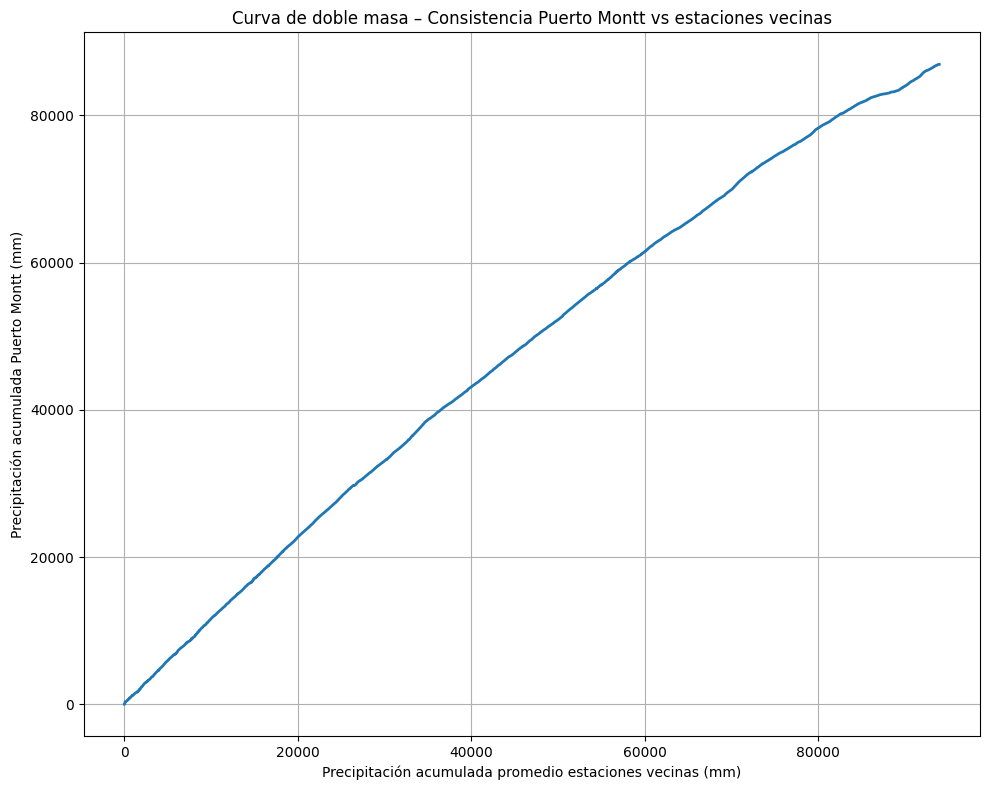

In [63]:
# -----------------------------------------
# Curva de doble masa:
# Puerto Montt vs promedio acumulado de estaciones vecinas
# -----------------------------------------

# 1. Crear serie promedio de estaciones vecinas
df_todas_estaciones["Promedio_vecinas"] = df_todas_estaciones[
    ["Tepual", "Puelo", "LagoChapo"]
].mean(axis=1)

# 2. Seleccionar solo fechas con datos completos
df_doble_masa = df_todas_estaciones[
    ["PuertoMontt_original", "Promedio_vecinas"]
].dropna()

# 3. Calcular acumulados
df_doble_masa["PuertoMontt_acum"] = df_doble_masa["PuertoMontt_original"].cumsum()
df_doble_masa["Vecinas_acum"] = df_doble_masa["Promedio_vecinas"].cumsum()

# 4. Graficar curva de doble masa
plt.figure(figsize=(10,8))

plt.plot(
    df_doble_masa["Vecinas_acum"],
    df_doble_masa["PuertoMontt_acum"],
    linewidth=2
)

# Línea de referencia ideal
xmin = df_doble_masa["Vecinas_acum"].min()
xmax = df_doble_masa["Vecinas_acum"].max()
ymin = df_doble_masa["PuertoMontt_acum"].min()
ymax = df_doble_masa["PuertoMontt_acum"].max()

plt.xlabel("Precipitación acumulada promedio estaciones vecinas (mm)")
plt.ylabel("Precipitación acumulada Puerto Montt (mm)")
plt.title("Curva de doble masa – Consistencia Puerto Montt vs estaciones vecinas")

plt.grid(True)
plt.tight_layout()
plt.show()

La relación es bastante lineal durante gran parte del registro.

👉 Esto sugiere que la serie de Puerto Montt es consistente respecto a las estaciones vecinas.

En términos prácticos:
No hay evidencia fuerte de cambios abruptos en instrumento
No se observan quiebres grandes por cambio de ubicación
No hay señales claras de sesgos sistemáticos mayores

Ahora miremos estos dos ejemplos muestran curvas doble acumuladas típicas donde es posible apreciar los efectos de cambios en las condiciones de medición
o errores groseros en la estadís􀆟ca.

<p align="center">
  <img src="https://raw.githubusercontent.com/paulmunozpauta/Hidrology_Course/main/Static/Imgs/Curva_doble_masa_1.png" width="700">
</p>
<p align="center">
  <img src="https://raw.githubusercontent.com/paulmunozpauta/Hidrology_Course/main/Static/Imgs/Curva_doble_masa_2.png" width="700">
</p>





## Intensidad de precipitación